In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r'C:\Users\Dr.SRINIVASA T\Downloads\Student_Behaviour.csv')
# Load top 5 rows
df.head()

,Certification Course,Gender,Department,Height(CM),Weight(KG),10th Mark,12th Mark,college mark,hobbies,daily studing time,prefer to study in,salary expectation,Do you like your degree?,willingness to pursue a career based on their degree,social medai & video,Travelling Time,Stress Level,Financial Status,part-time job
0,No,Male,BCA,100.0,58.0,79.0,65.0,80.0,Video Games,0 - 30 minute,Morning,40000,No,50%,1.30 - 2 hour,30 - 60 minutes,Bad,Bad,No
1,No,Female,BCA,90.0,40.0,70.0,80.0,70.0,Cinema,30 - 60 minute,Morning,15000,Yes,75%,1 - 1.30 hour,0 - 30 minutes,Bad,Bad,No
2,Yes,Male,BCA,159.0,78.0,69.5,61.0,55.0,Cinema,1 - 2 Hour,Anytime,13000,Yes,50%,More than 2 hour,30 - 60 minutes,Awful,Bad,No
3,Yes,Female,BCA,147.0,20.0,70.0,59.0,58.0,Reading books,1 - 2 Hour,Anytime,1500000,No,50%,1.30 - 2 hour,0 - 30 minutes,Bad,good,No
4,No,Male,BCA,170.0,54.0,40.0,65.0,30.0,Video Games,30 - 60 minute,Morning,50000,Yes,25%,1.30 - 2 hour,30 - 60 minutes,Good,good,No


In [29]:
# importing necessary libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

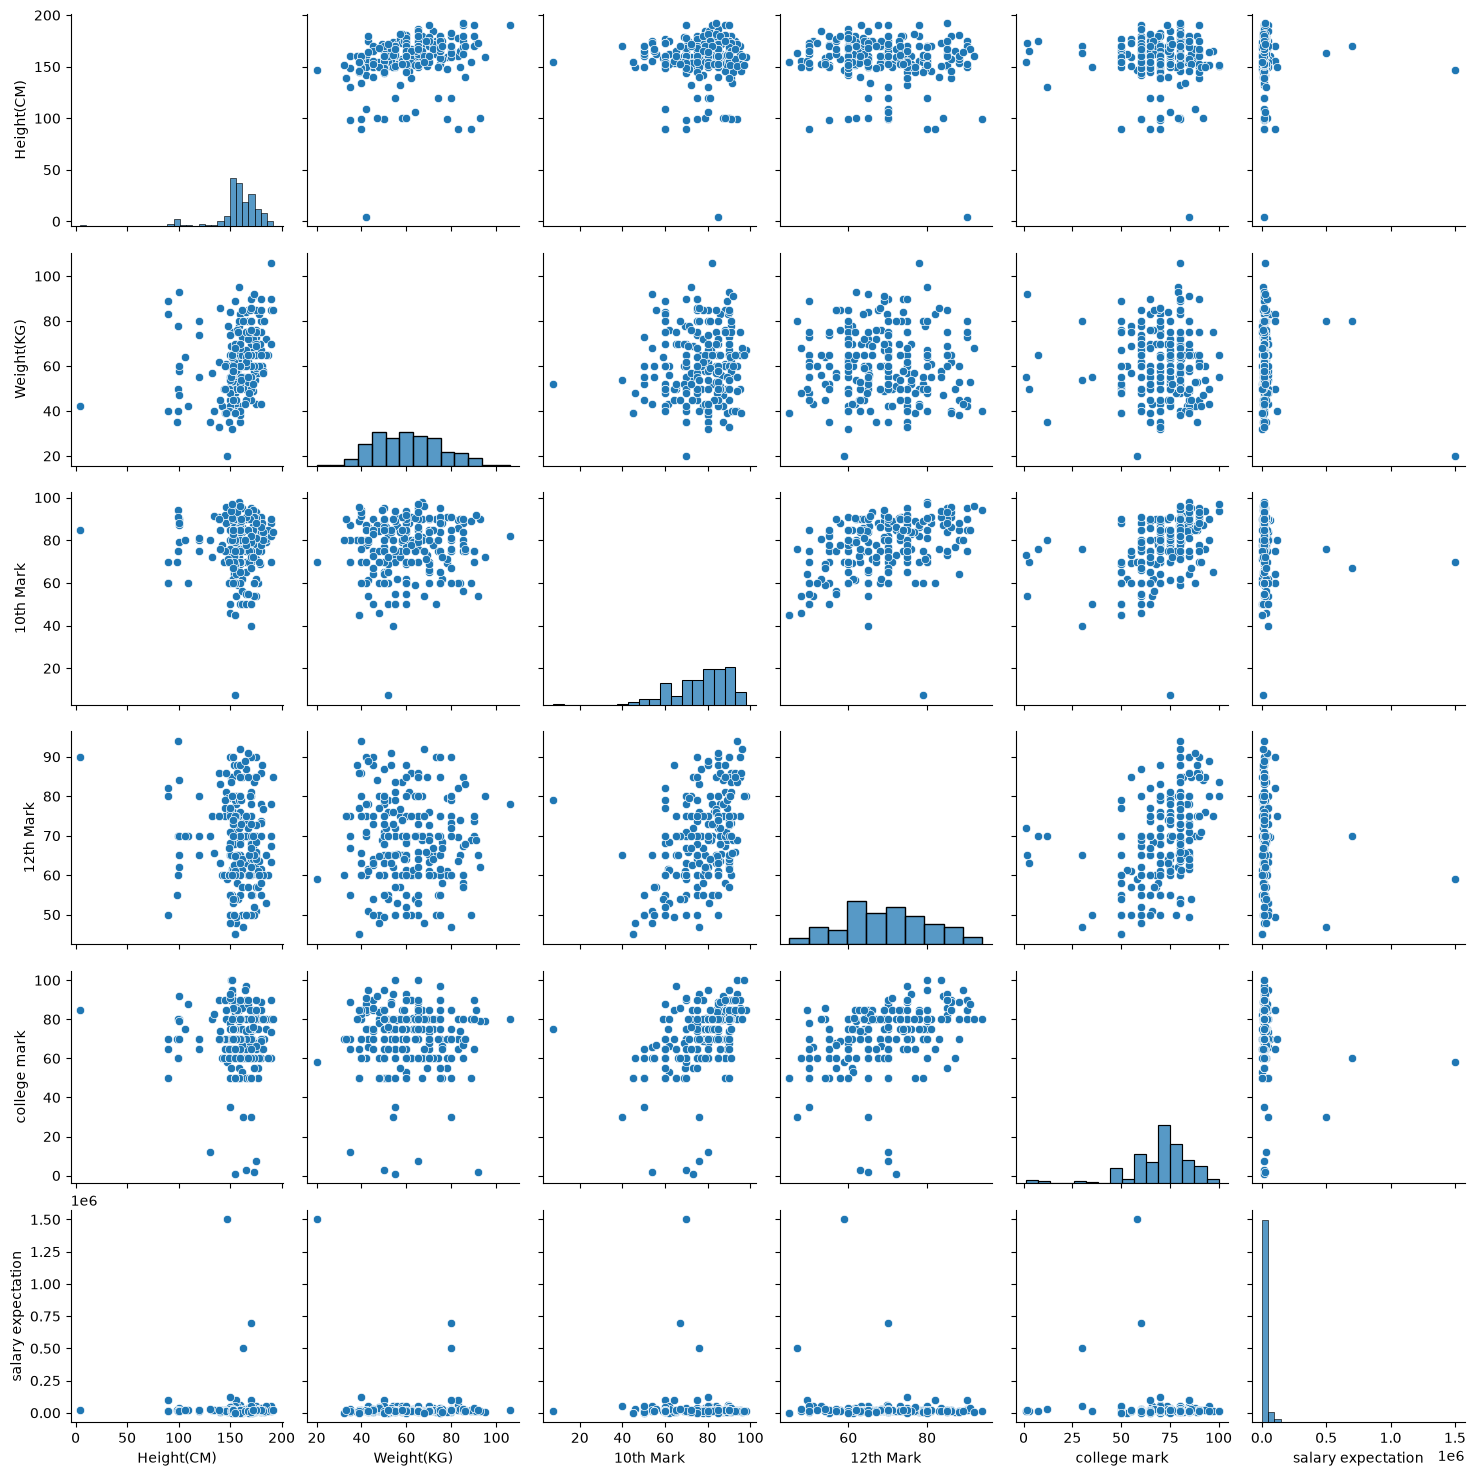

In [8]:
# pairplot
sns.pairplot(data=df)

In [9]:
#filtering
df[['Department','Gender']].value_counts()

Department                     Gender
BCA                            Male      94
                               Female    38
Commerce                       Male      31
                               Female    29
B.com ISM                      Male      22
B.com Accounting and Finance   Male       9
B.com ISM                      Female     6
B.com Accounting and Finance   Female     6
Name: count, dtype: int64

In [11]:
df[df['Department']=='BCA'].shape[0]

132

In [14]:
df[(df['Department']=='BCA')&(df['Gender']=='Female')].shape[0]

38

In [15]:
df[(df['Department']=='Commerce')&(df['Gender']=='Male')].shape[0]

31

In [18]:
df[(df['Department']=='B.com ISM')&(df['Gender']=='Female')].shape[0]

6

In [24]:
df[df['Stress Level ']=='Bad'].shape[0]

68

In [25]:
df['Stress Level '].unique()

array(['Bad', 'Awful', 'Good', 'fabulous'], dtype=object)

In [26]:
df[(df['Department']=='BCA')&(df['Stress Level ']=='fabulous')].shape[0]

3

In [27]:
df.columns

Index(['Certification Course', 'Gender', 'Department', 'Height(CM)',
       'Weight(KG)', '10th Mark', '12th Mark', 'college mark', 'hobbies',
       'daily studing time', 'prefer to study in', 'salary expectation',
       'Do you like your degree?',
       'willingness to pursue a career based on their degree  ',
       'social medai & video', 'Travelling Time ', 'Stress Level ',
       'Financial Status', 'part-time job'],
      dtype='object')

In [28]:
df['prefer to study in'].unique()

array(['Morning', 'Anytime', 'Night'], dtype=object)

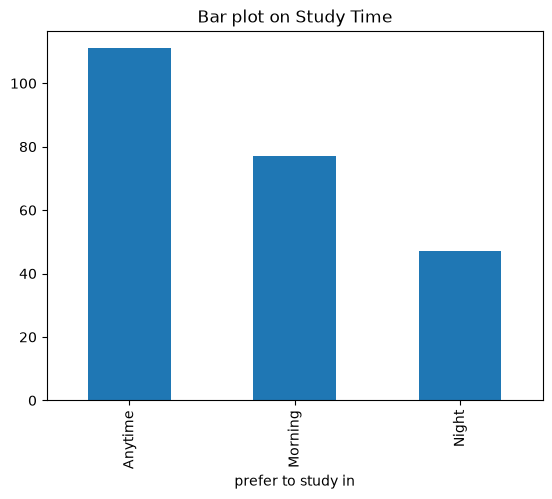

In [30]:
df['prefer to study in'].value_counts().plot(kind='bar')
plt.title('Bar plot on Study Time')
plt.show()

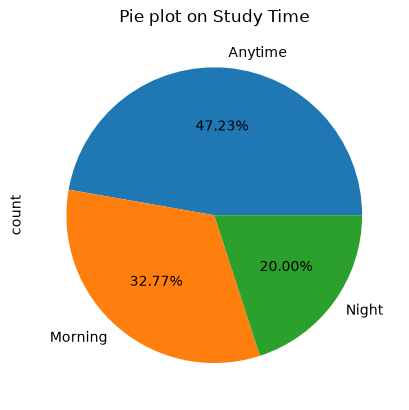

In [32]:
df['prefer to study in'].value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.title('Pie plot on Study Time')
plt.show()

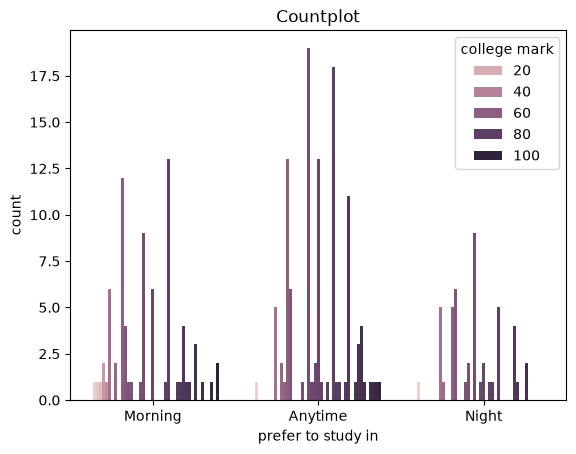

In [34]:
sns.countplot(data=df,x='prefer to study in',hue='college mark')
plt.title("Countplot")
plt.show()

In [35]:
df['salary expectation'].unique()

array([  40000,   15000,   13000, 1500000,   50000,   20000,   25000,
         18000,      17,   60000,       0,   30000,   10000,   17000,
        100000,    8000,   12000,      21,   35000,   16000,    5000,
         12500,   11000,  120000,   45000,   23000,  500000,  700000,
            10,      15,      22,     100,     500,    7000])

In [36]:
df['salary expectation'].max()

np.int64(1500000)

In [37]:
df['salary expectation'].min()

np.int64(0)

In [38]:
df['salary expectation'].mean()

np.float64(32481.68085106383)

<h1>Machine Learning - Supervised Learning</h1>

In [45]:
# import necessary libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
hr=pd.read_csv(r'C:\Users\Dr.SRINIVASA T\Downloads\Lab 21 House_Rent_Dataset.csv')
hr.head(3)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner


In [52]:
hr.shape

(4746, 12)

In [53]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [54]:
hr.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [55]:
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [57]:
hr['Furnishing Status'].unique()

array(['Unfurnished', 'Semi-Furnished', 'Furnished'], dtype=object)

In [58]:
hr['Tenant Preferred'].unique()

array(['Bachelors/Family', 'Bachelors', 'Family'], dtype=object)

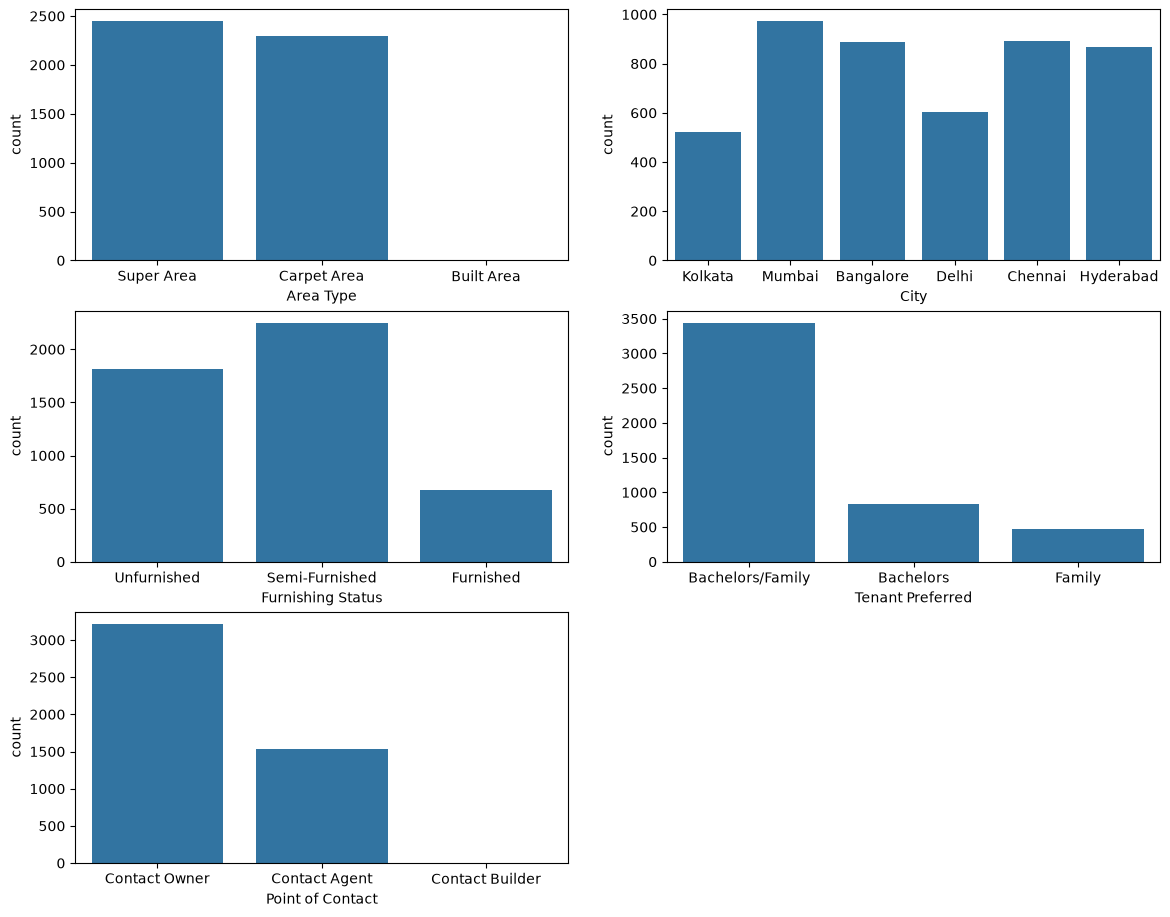

In [63]:
plt.figure(figsize=(14, 15))

for i,col in enumerate(["Area Type",
    "City",
    "Furnishing Status",
    "Tenant Preferred",
    "Point of Contact"]):

  plt.subplot(4, 2, i + 1)  
  sns.countplot(data=hr, x=col)

